In [32]:
import os
import random
from PIL import Image

import matplotlib.pyplot as plt

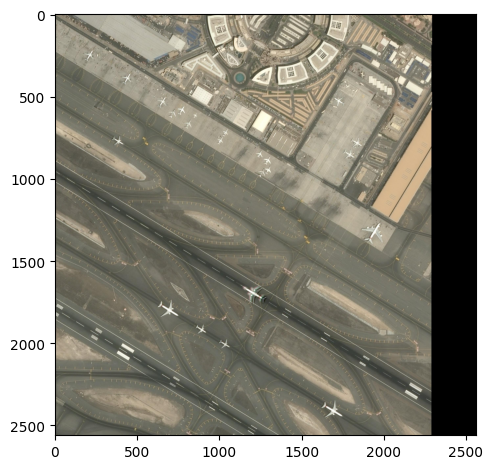

In [33]:
PATH_TEST = '/home/f.danilov/workflow/PAC_course2_2/AI/laba3/dataset/test'
test_list_dir = os.listdir(path=os.path.join(PATH_TEST, "images"))

img_path = random.choice(test_list_dir)
img_path = os.path.join(PATH_TEST, f"images/{img_path}")
if(os.path.exists(img_path)):
    img = Image.open(img_path).convert('RGB')
    plt.figsize=(15, 5)
    plt.imshow(img)
    
    plt.tight_layout()
    plt.show()


In [34]:
from ultralytics import YOLO
from ultralytics.utils import LOGGER
import logging

LOGGER.setLevel(logging.INFO)

import sys
handler = logging.StreamHandler(sys.stdout)
handler.setLevel(logging.INFO)
LOGGER.addHandler(handler)

model = YOLO('/home/f.danilov/workflow/PAC_course2_2/AI/laba3/yolov8n.pt')

results = model.train(
    data='/home/f.danilov/workflow/PAC_course2_2/AI/laba3/dataset/data.yaml',
    epochs=200,      
    batch=32,
    device=0,
    verbose=True
)

Ultralytics 8.4.47 🚀 Python-3.10.12 torch-2.7.1+cu118 CUDA:0 (Tesla V100-SXM2-32GB, 32494MiB)
Ultralytics 8.4.47 🚀 Python-3.10.12 torch-2.7.1+cu118 CUDA:0 (Tesla V100-SXM2-32GB, 32494MiB)
Ultralytics 8.4.47 🚀 Python-3.10.12 torch-2.7.1+cu118 CUDA:0 (Tesla V100-SXM2-32GB, 32494MiB)
Ultralytics 8.4.47 🚀 Python-3.10.12 torch-2.7.1+cu118 CUDA:0 (Tesla V100-SXM2-32GB, 32494MiB)
Ultralytics 8.4.47 🚀 Python-3.10.12 torch-2.7.1+cu118 CUDA:0 (Tesla V100-SXM2-32GB, 32494MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/f.danilov/workflow/PAC_course2_2/AI/laba3/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.

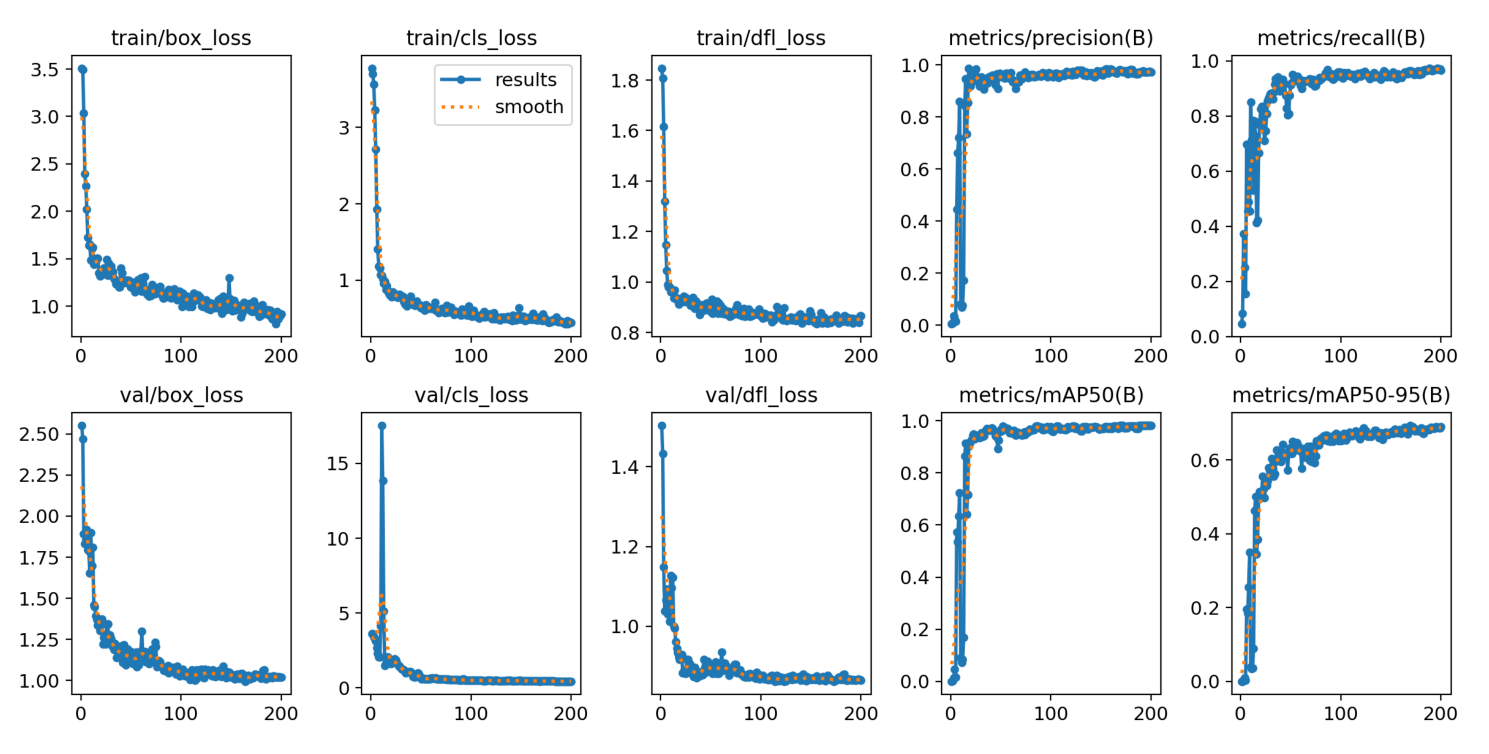

In [35]:
METRICS_DIR = '/home/f.danilov/workflow/PAC_course2_2/AI/laba3/runs/detect/train'
metrics_dir = os.listdir(METRICS_DIR)
plt.figure(figsize=(15, 10))
results = Image.open(os.path.join(METRICS_DIR, 'results.png'))
plt.imshow(results)
plt.axis('off')
plt.tight_layout()
plt.show()

In [36]:
graphs = []
for file_path in metrics_dir:
    if 'curve' in file_path:
        graphs.append(file_path)

print(len(graphs))

4


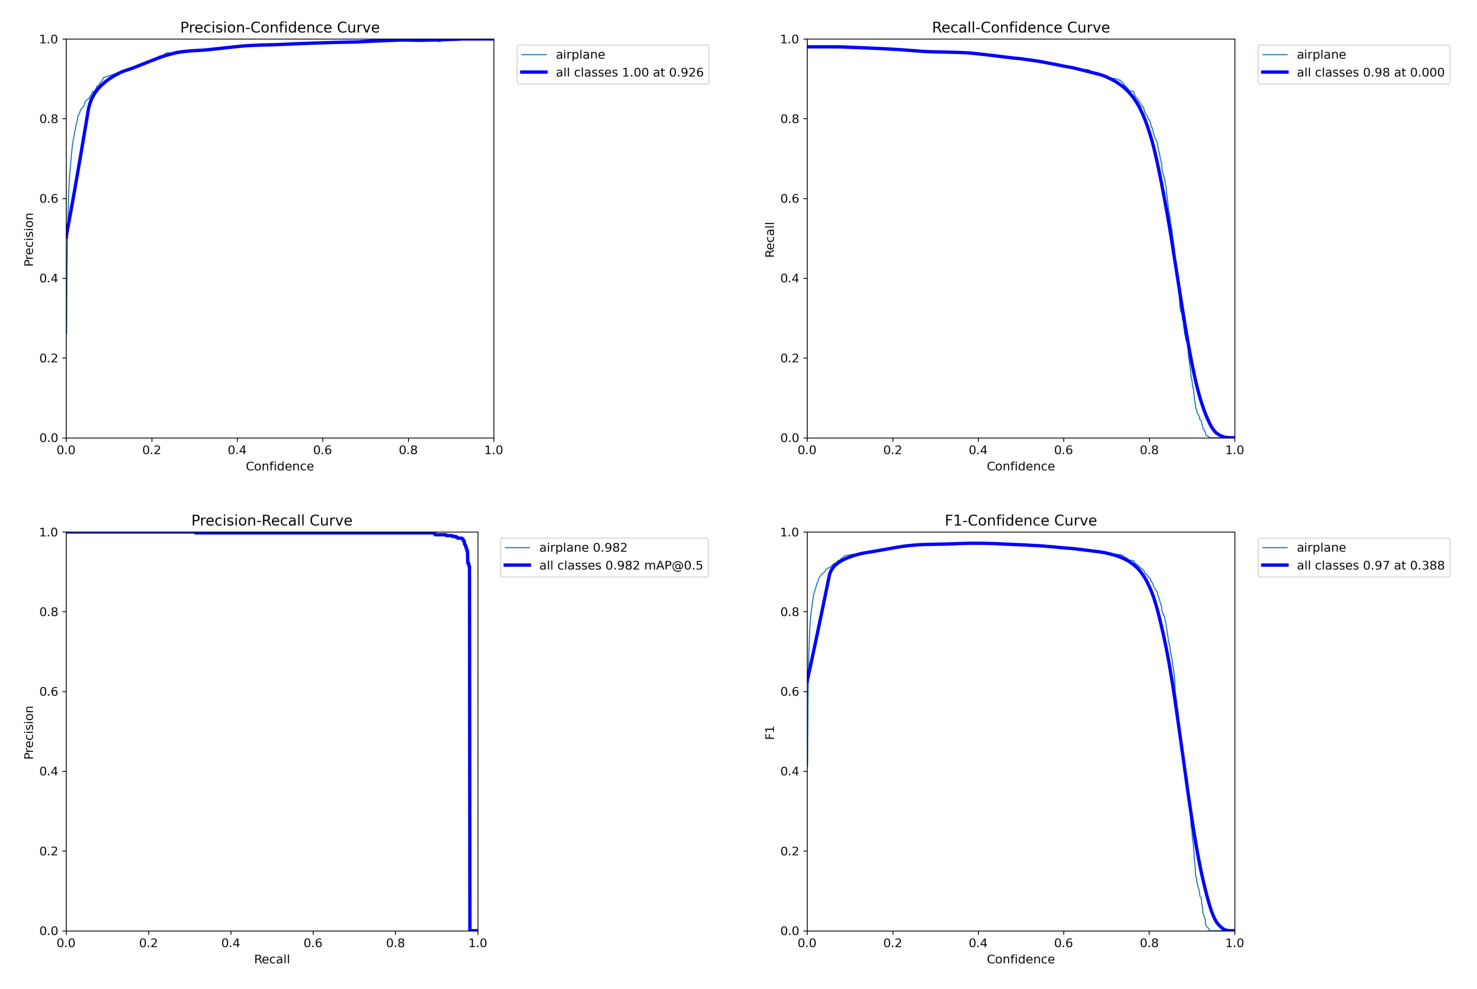

In [37]:
import math

cols = 2
rows = math.ceil(len(graphs) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = axes.flatten()  

for idx, file_path in enumerate(graphs):
    full_img_path = os.path.join(METRICS_DIR, file_path)
    img_idx = Image.open(full_img_path)

    axes[idx].imshow(img_idx)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [38]:
model = YOLO('runs/detect/train/weights/best.pt')
test_images_path = '/home/f.danilov/workflow/PAC_course2_2/AI/laba3/dataset/test'
test_images = os.listdir(os.path.join(test_images_path, 'images'))
size = len(test_images)
print(size)
print(test_images)

20
['cc4f3226-c262-409e-a4b2-a576e776f7f4.jpg', '4fdabd34-a2fd-4f0a-bb48-01fe043f1499.jpg', '3463b88d-1e11-4c04-9868-e8c72d510556.jpg', 'fc1ab8ce-e531-46ed-b74b-0374cd58cf2a.jpg', '791377f0-a01c-4fc3-b6e9-151b6cb80fdf.jpg', '4ca65749-67e4-4457-b4e4-89a3f58ce24d.jpg', 'eeb978ec-5945-4def-819a-4ea903b17c2d.jpg', 'bed88cf9-7887-4bfd-a1d7-b5499ee24f03.jpg', 'b3324b5e-cca9-42f7-9806-ab1f86eee050.jpg', 'e9021b38-0b3c-484f-af2c-b36bbf765f85.jpg', '22457f2e-a740-4719-9512-056749695281.jpg', '0641acc3-c0b9-4f9d-b0ba-7ad18aa08864.jpg', '56765c5f-0922-43b3-8d58-bf2bf5a1e727.jpg', 'fc06c595-7905-46c3-91c0-daf56af0f926.jpg', '20bfce20-fb8a-4e20-a4aa-57064add848b.jpg', '074737f4-7f59-4729-be5d-67f6f1d34668.jpg', '4e8c95f3-bbb6-4e2f-920d-8d3b2bd1d29f.jpg', '4e9164aa-532e-4b76-bce4-060b090da357.jpg', 'dacabde6-c8a7-475b-ab26-81b4e4dd5977.jpg', '2314c1b5-ec8f-4212-b42f-43365a13fd20.jpg']







image 1/1 /home/f.danilov/workflow/PAC_course2_2/AI/laba3/dataset/test/images/0641acc3-c0b9-4f9d-b0ba-7ad18aa08864.jpg: 640x640 23 airplanes, 7.8ms
image 1/1 /home/f.danilov/workflow/PAC_course2_2/AI/laba3/dataset/test/images/0641acc3-c0b9-4f9d-b0ba-7ad18aa08864.jpg: 640x640 23 airplanes, 7.8ms
image 1/1 /home/f.danilov/workflow/PAC_course2_2/AI/laba3/dataset/test/images/0641acc3-c0b9-4f9d-b0ba-7ad18aa08864.jpg: 640x640 23 airplanes, 7.8ms
image 1/1 /home/f.danilov/workflow/PAC_course2_2/AI/laba3/dataset/test/images/0641acc3-c0b9-4f9d-b0ba-7ad18aa08864.jpg: 640x640 23 airplanes, 7.8ms
image 1/1 /home/f.danilov/workflow/PAC_course2_2/AI/laba3/dataset/test/images/0641acc3-c0b9-4f9d-b0ba-7ad18aa08864.jpg: 640x640 23 airplanes, 7.8ms
Speed: 3.8ms preprocess, 7.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Speed: 3.8ms preprocess, 7.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Speed: 3.8ms preprocess, 7.8ms inference, 1.6ms postprocess per

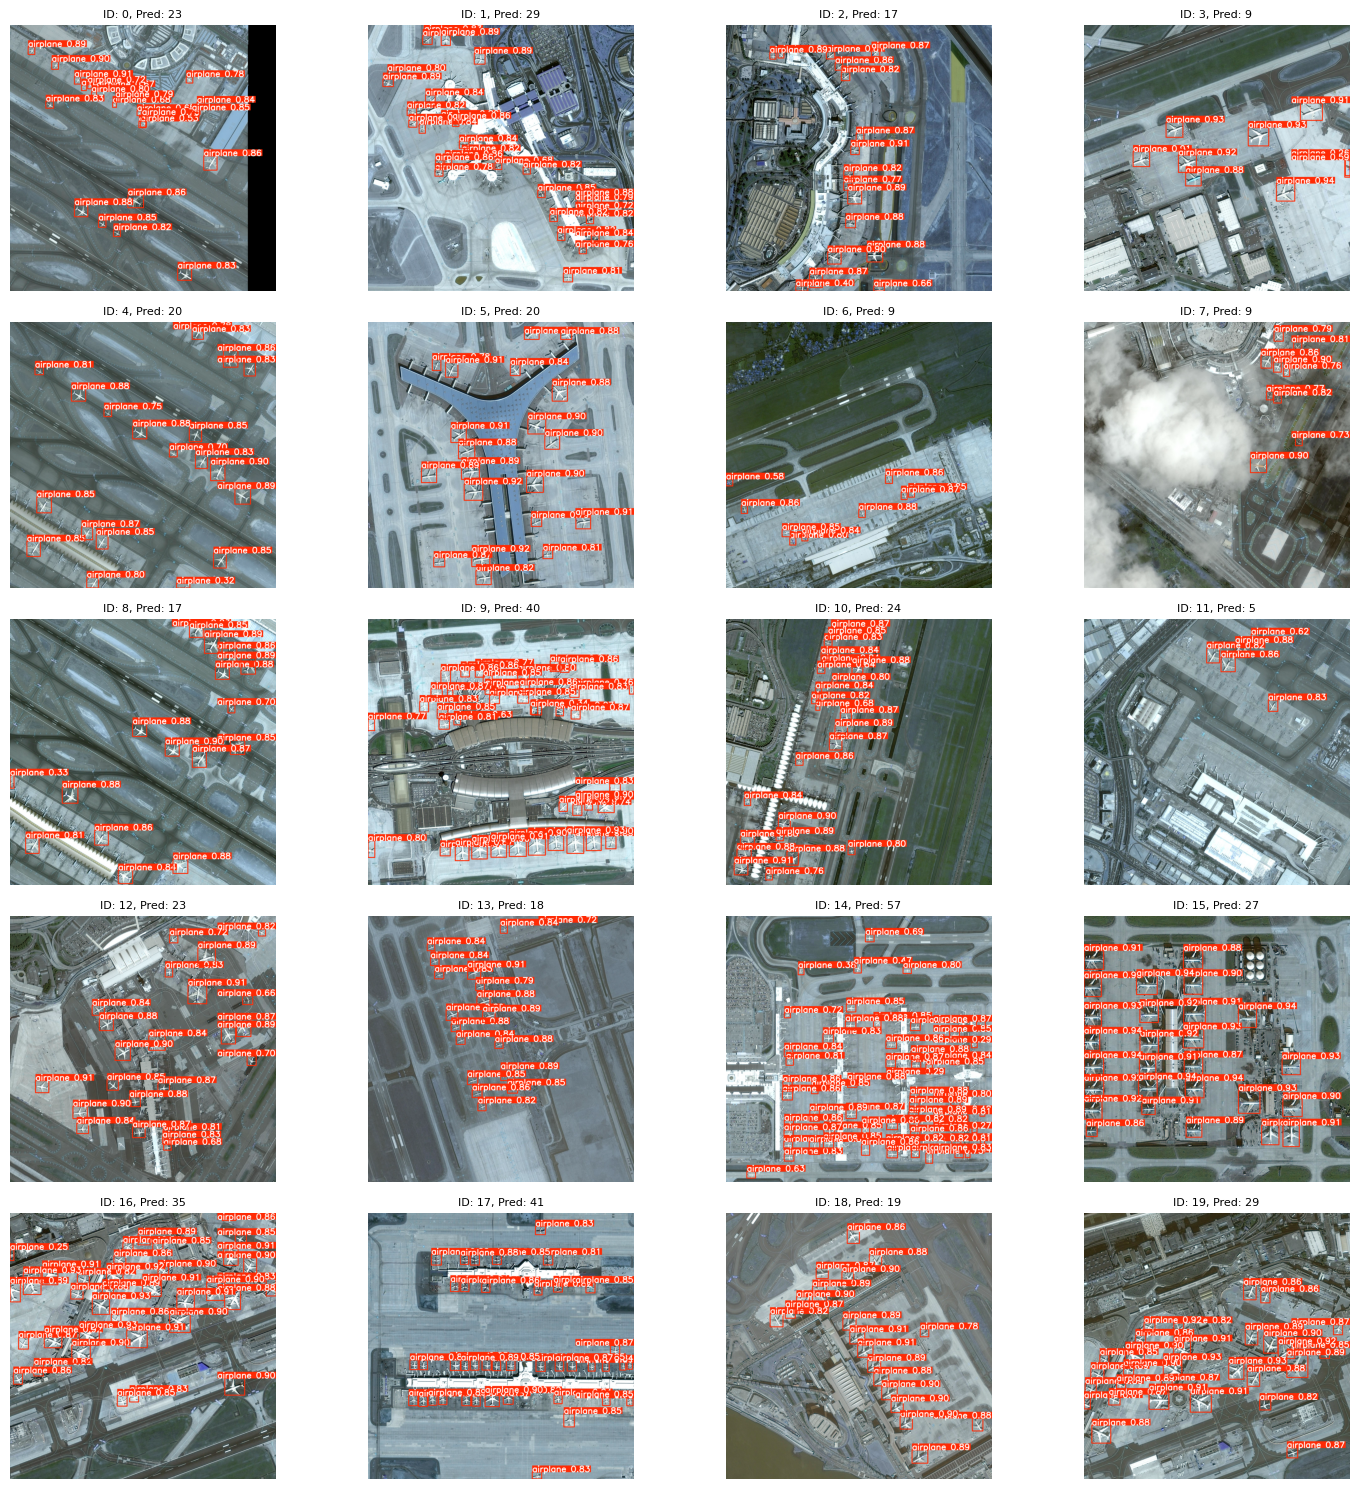

In [40]:
import math

cols = 4
rows = math.ceil(size / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
axes = axes.flatten()  

for idx, img_path in enumerate(sorted(test_images)):
    full_img_path = os.path.join(test_images_path, f'images/{img_path}')
    result = model(full_img_path)
    result = result[0]

    boxes = result.boxes.xyxy.cpu().numpy() if result.boxes is not None else []
    annotated_img = result.plot()

    axes[idx].imshow(annotated_img)
    axes[idx].set_title(f'ID: {idx}, Pred: {len(boxes)}', fontsize=8)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()